In [3]:
#資料處理Lib
import pandas as pd
import numpy as np
import datetime as dt
import scipy.stats as stats #可不用
from statsmodels.tsa import stattools
from statsmodels.graphics.tsaplots import *


#用來畫圖的Lib
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
#讀取excel資料
Price = pd.read_excel("Price01.xlsx")

In [5]:
#顯示部分數據
Price.head()

,Ticker,2016-01-29 00:00:00,2016-01-30 00:00:00,2016-02-01 00:00:00,2016-02-02 00:00:00,2016-02-03 00:00:00,2016-02-15 00:00:00,2016-02-16 00:00:00,2016-02-17 00:00:00,2016-02-18 00:00:00,...,2022-04-28 00:00:00,2022-04-29 00:00:00,2022-05-03 00:00:00,2022-05-04 00:00:00,2022-05-05 00:00:00,2022-05-06 00:00:00,2022-05-09 00:00:00,2022-05-10 00:00:00,2022-05-11 00:00:00,2022-05-12 00:00:00
0,2317,77.8,78.20,79.50,78.4,76.60,74.7,76.6,76.70,77.70,...,101.50,102.00,102.5,104.00,104.5,104.00,104,104.00,103.00,102.00
1,2330,143.0,142.00,144.00,142.5,146.00,145.0,147.5,148.00,151.00,...,531.00,538.00,531.0,534.00,542.0,528.00,520,518.00,521.00,505.00
2,2618,17.4,17.55,17.30,17.4,17.15,17.3,17.5,17.65,17.40,...,33.75,35.65,35.5,35.70,35.9,36.20,35,35.70,34.55,31.15
3,3078,21.3,21.70,21.35,21.3,21.35,21.8,21.8,22.50,22.45,...,35.50,35.70,35.7,35.75,35.9,35.85,35,34.95,34.50,33.75


In [6]:
Price1 = Price.rename(columns={'Ticker' : 'Date'})
Price1

,Date,2016-01-29 00:00:00,2016-01-30 00:00:00,2016-02-01 00:00:00,2016-02-02 00:00:00,2016-02-03 00:00:00,2016-02-15 00:00:00,2016-02-16 00:00:00,2016-02-17 00:00:00,2016-02-18 00:00:00,...,2022-04-28 00:00:00,2022-04-29 00:00:00,2022-05-03 00:00:00,2022-05-04 00:00:00,2022-05-05 00:00:00,2022-05-06 00:00:00,2022-05-09 00:00:00,2022-05-10 00:00:00,2022-05-11 00:00:00,2022-05-12 00:00:00
0,2317,77.8,78.20,79.50,78.4,76.60,74.7,76.6,76.70,77.70,...,101.50,102.00,102.5,104.00,104.5,104.00,104,104.00,103.00,102.00
1,2330,143.0,142.00,144.00,142.5,146.00,145.0,147.5,148.00,151.00,...,531.00,538.00,531.0,534.00,542.0,528.00,520,518.00,521.00,505.00
2,2618,17.4,17.55,17.30,17.4,17.15,17.3,17.5,17.65,17.40,...,33.75,35.65,35.5,35.70,35.9,36.20,35,35.70,34.55,31.15
3,3078,21.3,21.70,21.35,21.3,21.35,21.8,21.8,22.50,22.45,...,35.50,35.70,35.7,35.75,35.9,35.85,35,34.95,34.50,33.75


In [7]:
#檢查是否有空值
Price1.isna().sum().sum()

7

In [8]:
#填空值 : 填入前一個有效值
Price2 = Price1.fillna(method='ffill',axis=1)

In [9]:
Price2.isna().sum().sum()

0

In [10]:
#將Date設為index，並將矩陣轉置
Price3 = Price2.set_index('Date').T

#將時間設為變數，並轉為數值
Price3.columns=["2317","2330","2618","3078"]
Price3.head()

,2317,2330,2618,3078
2016-01-29 00:00:00,77.8,143.0,17.40,21.30
2016-01-30 00:00:00,78.2,142.0,17.55,21.70
2016-02-01 00:00:00,79.5,144.0,17.30,21.35
2016-02-02 00:00:00,78.4,142.5,17.40,21.30
2016-02-03 00:00:00,76.6,146.0,17.15,21.35


In [11]:
Price3.index = pd.to_datetime(Price3.index)
Price3

,2317,2330,2618,3078
2016-01-29,77.8,143.0,17.40,21.30
2016-01-30,78.2,142.0,17.55,21.70
2016-02-01,79.5,144.0,17.30,21.35
2016-02-02,78.4,142.5,17.40,21.30
2016-02-03,76.6,146.0,17.15,21.35
...,...,...,...,...
2022-05-06,104.0,528.0,36.20,35.85
2022-05-09,104.0,520.0,35.00,35.00
2022-05-10,104.0,518.0,35.70,34.95
2022-05-11,103.0,521.0,34.55,34.50


## 時間序列分析

In [12]:
Price_2330 = Price3.drop({'2317','3078','2618'},axis=1)

In [13]:
#計算Return
Price_2330["Return"] = Price_2330["2330"].pct_change()
Price_2330 = Price_2330.fillna(0)

Price_2330

,2330,Return
2016-01-29,143.0,0.000000
2016-01-30,142.0,-0.006993
2016-02-01,144.0,0.014085
2016-02-02,142.5,-0.010417
2016-02-03,146.0,0.024561
...,...,...
2022-05-06,528.0,-0.025830
2022-05-09,520.0,-0.015152
2022-05-10,518.0,-0.003846
2022-05-11,521.0,0.005792


<AxesSubplot:>

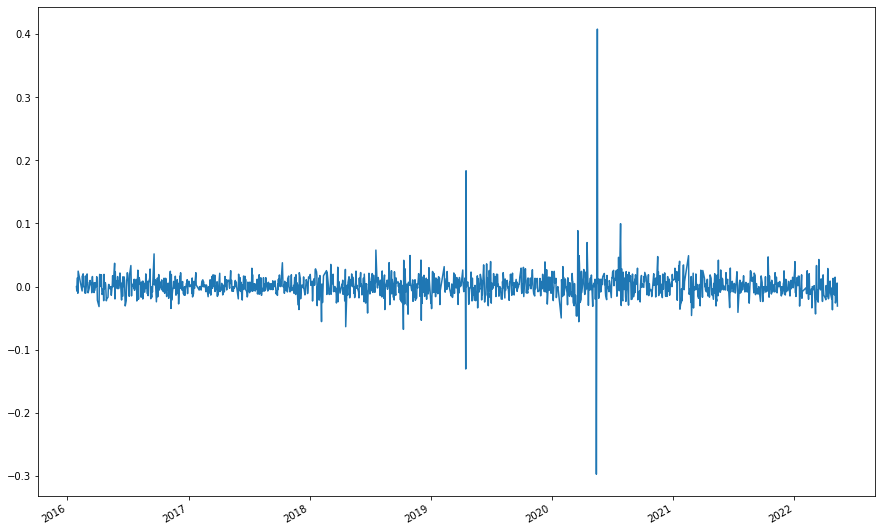

In [14]:
# Return 
Price_2330["Return"].plot(figsize=(15,10))

## 自相關性

In [15]:
#計算自相關係數
acfs = stattools.acf(Price_2330["Return"])
acfs

array([ 1.00000000e+00, -2.24575169e-01,  1.35714217e-03,  6.79667802e-03,
       -4.61158206e-02,  3.48293473e-03, -5.44089953e-03,  1.63190911e-02,
        3.24031773e-02,  6.04851239e-03, -1.85058893e-02, -2.41765620e-02,
        2.48153370e-02, -1.30863028e-02,  7.17351122e-03,  5.13898779e-02,
       -3.05660626e-02,  4.04590349e-04,  2.04525122e-04, -3.29612055e-02,
        3.27141396e-02,  7.22502992e-03, -1.27851030e-03,  1.60027637e-02,
       -4.35610485e-02, -8.56766949e-03, -1.45544351e-02,  4.81775682e-03,
       -1.33440153e-02,  2.05282453e-02,  2.30159768e-02,  3.16808649e-02])

In [16]:
#計算偏自相關係數
pacfs = stattools.pacf(Price_2330["Return"])
pacfs

array([ 1.00000000e+00, -2.24721950e-01, -5.17546449e-02, -4.75121916e-03,
       -4.81777634e-02, -1.89290143e-02, -1.19371648e-02,  1.29165239e-02,
        3.90071221e-02,  2.40705670e-02, -1.10315742e-02, -3.07221820e-02,
        1.60199950e-02, -3.30349032e-03,  3.13067064e-03,  5.29139857e-02,
       -7.38987295e-03, -7.13054544e-03,  7.33188932e-04, -2.88686713e-02,
        1.79437959e-02,  1.71624346e-02,  3.11320903e-03,  1.28941538e-02,
       -3.79966377e-02, -2.37429273e-02, -2.25211088e-02, -5.47364514e-03,
       -1.98592797e-02,  7.95905464e-03,  2.56366300e-02,  5.31454323e-02])

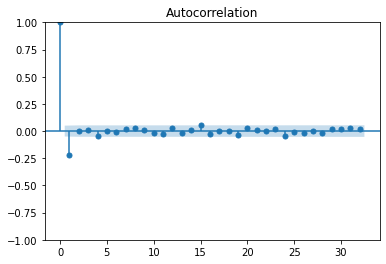

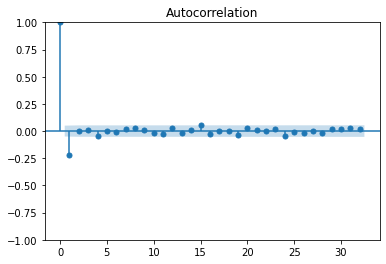

In [17]:
plot_acf(Price_2330["Return"])

C:\Users\Defaultuser\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


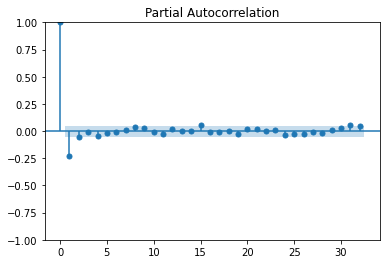

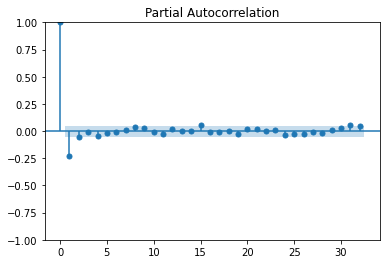

In [18]:
plot_pacf(Price_2330["Return"])

## 自動Arima

In [19]:
#https://reurl.cc/Lmn3G7
from pmdarima.arima import auto_arima

In [20]:
# 切分測試與訓練集
train = Price_2330[:1200]
valid = Price_2330[1200:]
 
training = train['2330']
validation = valid['2330']

In [21]:
#配置超參數範圍
model  = auto_arima(training, 
                    start_p=1, start_q=1,                     
                    max_p=3, max_q=3, 
                    test='adf',            #使用ADF TEST找到最好的d
                    d=None,
                    seasonal=True,
                    start_P=0, 
                    D=None, 
                    trace=True,
                    error_action='ignore',
                    suppress_warnings=True,
                    stepwise=True)

model.fit(training)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7485.193, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7548.808, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7486.478, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7483.230, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7550.352, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=7485.191, Time=0.27 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=7487.230, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=7487.651, Time=0.05 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.102 seconds


ARIMA(order=(0, 1, 1), scoring_args={}, suppress_warnings=True)

In [22]:
model

ARIMA(order=(0, 1, 1), scoring_args={}, suppress_warnings=True)

In [23]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1200
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -3738.615
Date:                Wed, 15 Jun 2022   AIC                           7483.230
Time:                        23:55:56   BIC                           7498.498
Sample:                             0   HQIC                          7488.982
                               - 1200                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3062      0.139      2.210      0.027       0.035       0.578
ma.L1         -0.2394      0.006    -39.069      0.000      -0.251      -0.227
sigma2        29.9151      0.229    130.626      0.000      29.466      30.364
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            277344.64
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):              15.84   Skew:                            -1.87
Prob(H) (two-sided):                  0.00   Kurtosis:                        77.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
forecast = model.predict(n_periods=331)
forecast = pd.DataFrame(forecast,index = valid.index,columns=['Prediction'])
forecast

,Prediction
2020-12-25,510.238397
2020-12-28,510.544595
2020-12-29,510.850792
2020-12-30,511.156990
2020-12-31,511.463188
...,...
2022-05-06,610.058894
2022-05-09,610.365091
2022-05-10,610.671289
2022-05-11,610.977487


In [25]:
rms=np.sqrt(np.mean(np.power((np.array(valid['2330'])-np.array(forecast['Prediction'])),2)))
rms

55.52037147436558

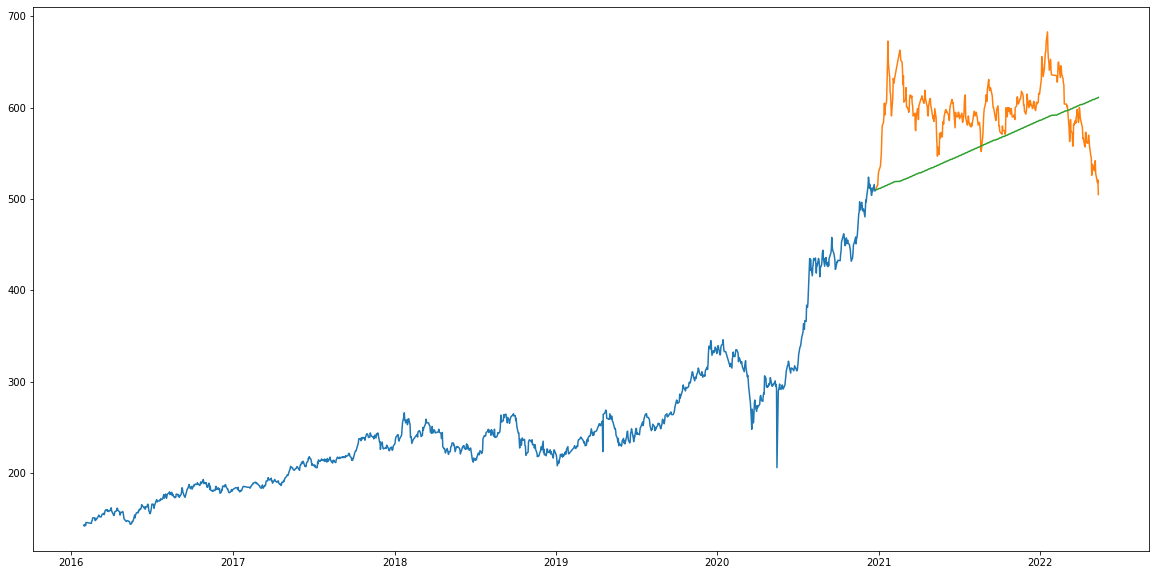

In [26]:
#plot
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,10

plt.plot(train['2330'])
plt.plot(valid['2330'])
plt.plot(forecast['Prediction'])

## 法二

In [27]:
train2 = Price_2330[:1200]
valid2 = Price_2330[1200:]
 
training2 = train2['Return']
validation2 = valid2['Return']

model2 = auto_arima(training2, 
                    start_p=1, start_q=1,                     
                    max_p=3, max_q=3,
                    test='adf',            #使用ADF TEST找到最好的d                    
                    d=None,
                    seasonal=True,
                    start_P=0,
                    m = 1,
                    D=None,                   
                    trace=True,
                    error_action='ignore',
                    suppress_warnings=True,
                    stepwise=True)

model2.fit(training2)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-5857.119, Time=0.17 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-5765.116, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-5853.165, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-5859.157, Time=0.17 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-5762.927, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-5857.159, Time=0.24 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-5855.160, Time=0.61 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-5852.337, Time=0.17 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 1.701 seconds


ARIMA(order=(0, 0, 1), scoring_args={}, suppress_warnings=True)

In [28]:
forecast2 = model2.predict(n_periods=331)
forecast2 = pd.DataFrame(forecast2,index = valid.index,columns=['Prediction2'])
forecast2

,Prediction2
2020-12-25,0.001481
2020-12-28,0.001289
2020-12-29,0.001289
2020-12-30,0.001289
2020-12-31,0.001289
...,...
2022-05-06,0.001289
2022-05-09,0.001289
2022-05-10,0.001289
2022-05-11,0.001289


In [29]:
rms=np.sqrt(np.mean(np.power((np.array(valid2['Return'])-np.array(forecast2['Prediction2'])),2)))
rms

0.015359539679627979

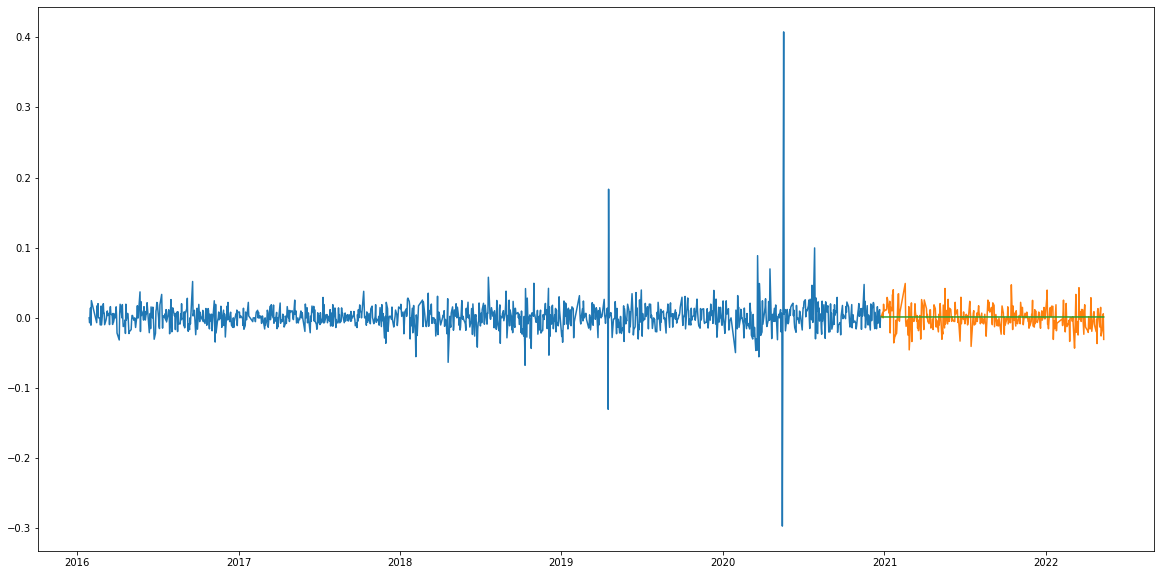

In [30]:
#plot
plt.plot(train2['Return'])
plt.plot(valid2['Return'])
plt.plot(forecast2['Prediction2'])

In [31]:
forecast2["Prediction3"]=0
forecast2["Prediction3"][0] = 510*(1+forecast2["Prediction2"][0])

for i in range(330):
    forecast2["Prediction3"][i+1] = forecast2["Prediction3"][i]*(1+forecast2["Prediction2"][i+1])
    
forecast2["Prediction3"]

C:\Users\Defaultuser\AppData\Local\Temp\ipykernel_7856\1338037387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast2["Prediction3"][0] = 510*(1+forecast2["Prediction2"][0])


ValueError: 

In [ ]:
#plot
plt.plot(train['2330'])
plt.plot(valid['2330'])
plt.plot(forecast2['Prediction3'])

## Garch

In [ ]:
from arch import arch_model

In [ ]:
RES = pd.DataFrame((np.array(valid2['Return'])-np.array(forecast2['Prediction2'])),index = valid.index,columns=['res'])
RES

In [ ]:
LjungBox = stattools.q_stat(stattools.acf(RES["res"]),len(RES["res"]))
LjungBox[1][-1]

In [ ]:
#arch_model默認建立GARCH(1,1)模型
am = arch_model(RES["res"])

In [ ]:
#update_freq=0表是不輸出過程，只輸出結果
model3 = am.fit(update_freq=0)

In [ ]:
print(model3.summary())